<a href="https://colab.research.google.com/github/Makande340/A03-knn/blob/main/kNN_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

# Phase 1 Question 1 answers

Q1.1 - Regression consists of the prediction of numerical values whereas classification consists of the prediction of categorical values.

Q1.2 - Complex matrixes/tables are utilized to count the number of predictions between actual and predicted classes

Q1.3 - SSE essentially quantifies the overall difference between actual/observed and predicted value points

Q1.4 - Underfitting is when the model itself lacks the bandwith to be able to capture relationships within the datasets outcomes. Overfitting is when model fits datatset feature will not prominently or consistently show up.

Q1.5 - Splitting the data is mportant because it allows for the avoidance of overfitting, all observations existing and new are accounted for balanced bias and variance awareness with generatlization towards observations that were not used.


Q1.6 - Class labels provide concrete assessment with clear communcation of value, but weakness is that model confidence is not clear/states
     - Prediction labels strength provides opportunity for uncertainty to be measured, quantified, and calculated, but a weakness is

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


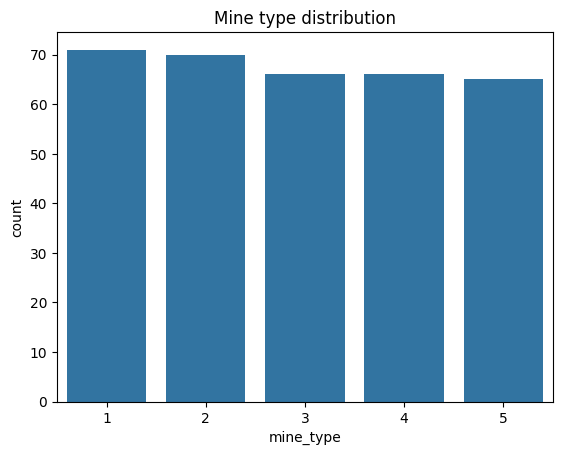

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
voltage    0
height     0
soil       0
dtype: int64
Duplicates: 0


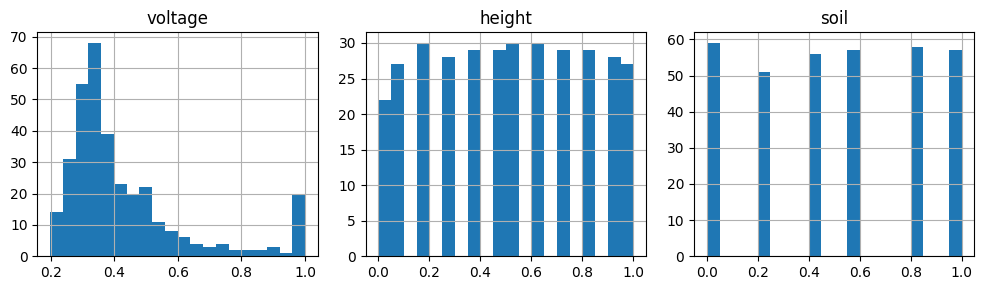

           train  valid
mine_type              
1             35     36
2             35     35
3             33     33
4             33     33
5             33     32
Best k: 2
Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
Accuracy: 0.46745562130177515
Actual
1    0.75
2    0.89
3    0.30
4    0.27
5    0.06
dtype: float64


In [15]:
#Q2.1:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

url = "./land_mines.csv"
df = pd.read_csv(url)
#data loading din din din din


target = "mine_type"
features = ["voltage", "height", "soil"]

print(df[target].value_counts().sort_index())
print(df[target].value_counts(normalize=True).sort_index())
sns.countplot(x=target, data=df)
plt.title("Mine type distribution")
plt.show()

print(df[features].describe())
print(df[features].isna().sum())
print("Duplicates:", df.duplicated().sum())

df[features].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

#target label can be seen as the mine type with it consisting of five catergorical classes that are balanced.
#feature include voltage (numeric), height (numeric), and soil (discrete levels).


#Q2.2


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, stratify=eval_y, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


print(pd.DataFrame({
    "train": eval_y_train.value_counts().sort_index(),
    "valid": eval_y_valid.value_counts().sort_index(),
}))
#splits into even training sets and validation sets using three key features of voltage, height, and soil

#Q2.3

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []
valid_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # k selected using cross-validation on the traning set
    cv_scores.append(cross_val_score(knn, eval_X_train_scaled, eval_y_train, cv=5).mean())
    # validation accuracy used for comparison
    knn.fit(eval_X_train_scaled, eval_y_train)
    valid_scores.append(knn.score(eval_X_valid_scaled, eval_y_valid))

best_k = k_values[int(np.argmax(cv_scores))]
print("Best k:", best_k)

#trained kNN classifierss on scaled trainin data, estimating accuracy with cross-validation on solely the training set

#Q2.4

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(eval_X_train_scaled, eval_y_train)
pred = knn.predict(eval_X_valid_scaled)

# confusion table
cm = pd.crosstab(eval_y_valid, pred, rownames=["Actual"], colnames=["Predicted"])
print(cm)

# accuracy
print("Accuracy:", accuracy_score(eval_y_valid, pred))

print((pd.Series(cm.values.diagonal(), index=cm.index) / cm.sum(axis=1)).round(2))

#k-NN model showcases 47% accuracy on the test set, above 20 perecent from random guessing. type 2 and type 1 boast the best at 89% and 75% respectively, the worst on type 3 and type 4,near failing at type 5
#perfomance at their best when voltage seperates class and worse when class overlaps

#Q2.5 -
#I would advise one to use the model as a reference but not as the set say for the type of mine itself. Types should be utilized as ways to verify, checks before anything is acted upon. Be wary of what is classified as type 1 because some types can be mislabled, important to take into account the possibilities of overlap

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**

- **AI tool and model used:** [Gemini]

### Q1 - Prompts used